# Analyse de l'anomalie Décembre 2025 — Janvier 2026

**Contexte** : sur cette période, les prédictions du modèle Ensemble sont significativement supérieures aux effectifs réels.  

Stratégie d'analyse :
1. Requête Trino avec toutes les variables explicatives (`is_holyday`, `is_ferie`, `is_bridge`, moyennes mobiles…)
2. Comparaison avec les autres modèles (Prophet, XGBoost, ARIMA) pour isoler si l'anomalie est propre à Ensemble ou partagée
3. Caractérisation : amplitude, établissements touchés, structure temporelle, rôle des features

## 1. Imports

In [1]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from dotenv import load_dotenv
from trino.dbapi import connect
from trino.auth import BasicAuthentication

warnings.filterwarnings('ignore')
load_dotenv()
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 110

# Période anomalie
ANOMALY_START = pd.Timestamp('2025-12-01')
ANOMALY_END   = pd.Timestamp('2026-01-31')
# Contexte élargi pour comparer avant/après
CONTEXT_START = pd.Timestamp('2025-09-01')
CONTEXT_END   = pd.Timestamp('2026-03-31')

BIN_ORDER = ['≤7j', '≤14j', '≤21j', '>21j']

ALL_MODELS = ['Ensemble', 'Prophet21', 'Prophet35', 'XGBoost21', 'XGBoost35', 'ARIMA', 'MovingAverage']

## 2. Chargement depuis Trino (avec variables explicatives + tous les modèles)

In [2]:
conn = connect(
    host='@data-ianord-query.eu.dataplatform.ovh.net',
    port=443,
    user=os.getenv('OVH_API_KEY'),
    auth=BasicAuthentication(os.getenv('OVH_API_KEY'), os.getenv('OVH_SECRET_KEY')),
    catalog='db_mg6jk45h_default_dataset',
    schema='default_dataset',
    http_scheme='https',
)
cursor = conn.cursor()

# Contexte large (sept 2025 → mars 2026) pour les comparaisons avant/après
cursor.execute("""
    SELECT
        prediction_date,
        target_date,
        horizon,
        uai,
        model,
        prediction,
        effectif_reel,
        service,
        is_holyday,
        is_ferie,
        is_bridge,
        is_day_usually_open,
        mobile_mean_42_shifted_21,
        mobile_mean_42_shifted_35,
        daily_mobile_mean_8_shifted_4,
        daily_mobile_mean_8_shifted_6,
        weekday_mean
    FROM db_mg6jk45h_default_dataset.default_dataset.passage_predict
    WHERE target_date BETWEEN DATE '2025-09-01' AND DATE '2026-03-31'
""")
rows = cursor.fetchall()
cols = [d[0] for d in cursor.description]
df = pd.DataFrame(rows, columns=cols)

df['target_date']     = pd.to_datetime(df['target_date'])
df['prediction_date'] = pd.to_datetime(df['prediction_date'])
df['horizon']         = df['horizon'].astype(int)
for col in ['is_holyday', 'is_ferie', 'is_bridge', 'is_day_usually_open']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

print(f"Lignes chargées : {len(df):,}")
print(f"Période         : {df['target_date'].min().date()} → {df['target_date'].max().date()}")
print(f"Modèles         : {sorted(df['model'].unique())}")
print(f"Établissements  : {df['uai'].nunique()}")

Lignes chargées : 612,044
Période         : 2025-09-01 → 2026-03-31
Modèles         : ['ARIMA', 'Ensemble', 'MovingAverage', 'Prophet21', 'Prophet35', 'XGBoost21', 'XGBoost35']
Établissements  : 196


In [3]:
# Table de référence des établissements
conn2 = connect(
    host='@data-ianord-query.eu.dataplatform.ovh.net',
    port=443,
    user=os.getenv('OVH_API_KEY'),
    auth=BasicAuthentication(os.getenv('OVH_API_KEY'), os.getenv('OVH_SECRET_KEY')),
    catalog='db_mg6jk45h_prodcentre',
    schema='prodcentre',
    http_scheme='https',
)
cur2 = conn2.cursor()
cur2.execute("SELECT login AS uai, nometabs, ville FROM db_mg6jk45h_prodcentre.prodcentre.wg_centre_login")
df_etab = pd.DataFrame(cur2.fetchall(), columns=['uai', 'nometabs', 'ville']).drop_duplicates('uai')
print(f"Établissements référence : {len(df_etab)}")

Établissements référence : 2485


## 3. Préparation — Binning horizon + label période

In [4]:
def assign_bin(h):
    if h <= 7:    return '≤7j'
    elif h <= 14: return '≤14j'
    elif h <= 21: return '≤21j'
    else:         return '>21j'

def build_binned(df_in):
    d = df_in.copy()
    d['horizon_bin'] = d['horizon'].apply(assign_bin)
    return (
        d.sort_values('horizon')
         .groupby(['target_date','uai','service','model','horizon_bin'], as_index=False)
         .first()
    )

def mape(actual, pred):
    mask = actual > 0
    if mask.sum() == 0: return np.nan
    return np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100

df_binned = build_binned(df)
df_binned['periode'] = np.where(
    (df_binned['target_date'] >= ANOMALY_START) & (df_binned['target_date'] <= ANOMALY_END),
    'Anomalie (Déc–Jan)', 'Reste'
)

def day_type(row):
    if row.get('is_ferie', 0):         return 'Férié'
    if row.get('is_holyday', 0):       return 'Vacances'
    if row.get('is_bridge', 0):        return 'Pont'
    if not row.get('is_day_usually_open', 1): return 'Fermé habituellement'
    return 'Normal'

df_binned['day_type'] = df_binned.apply(day_type, axis=1)

print(f"Lignes binnées : {len(df_binned):,}")
print("\nRépartition types de jours (sur les target_dates uniques) :")
print(df_binned.drop_duplicates('target_date')['day_type'].value_counts())

Lignes binnées : 552,665

Répartition types de jours (sur les target_dates uniques) :
day_type
Normal    130
Pont        1
Férié       1
Name: count, dtype: int64


## 4. Vue d'ensemble — Courbes journalières (tous modèles, horizon ≤7j)

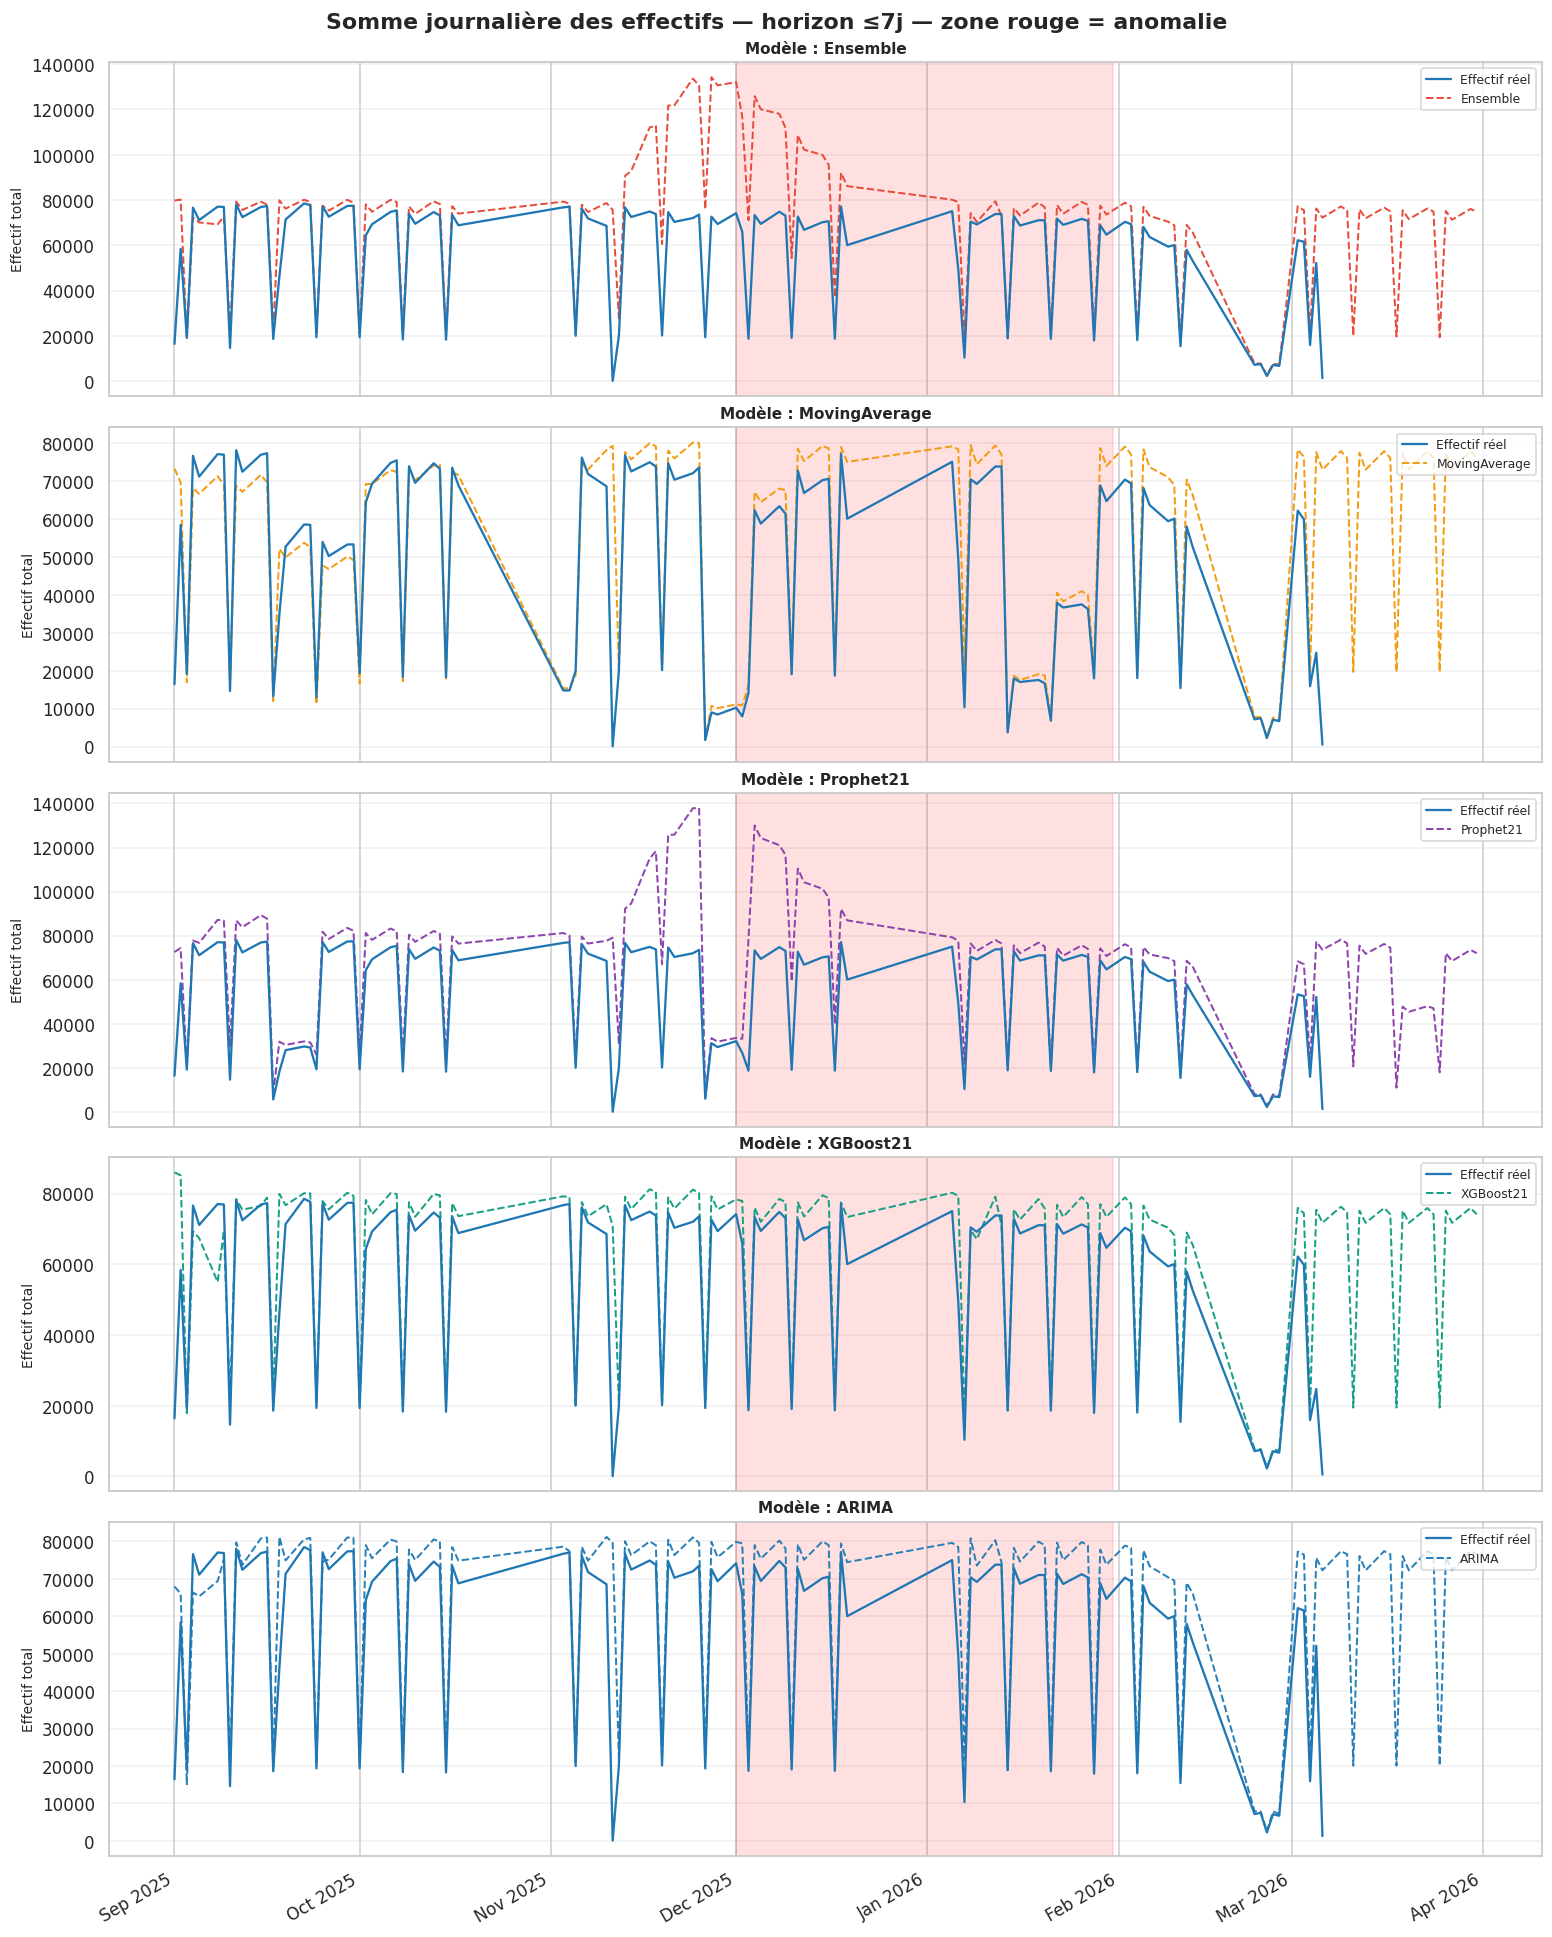

In [5]:
models_to_plot = ['Ensemble', 'MovingAverage', 'Prophet21', 'XGBoost21', 'ARIMA']
models_present = [m for m in models_to_plot if m in df_binned['model'].unique()]

sub7 = df_binned[df_binned['horizon_bin'] == '≤7j']

fig, axes = plt.subplots(len(models_present), 1,
                          figsize=(14, 3.5 * len(models_present)),
                          sharex=True, constrained_layout=True)
if len(models_present) == 1:
    axes = [axes]

colors = {'Ensemble': '#E74C3C', 'MovingAverage': '#F39C12',
          'Prophet21': '#8E44AD', 'XGBoost21': '#16A085', 'ARIMA': '#2980B9'}

for ax, model in zip(axes, models_present):
    sub_m = sub7[sub7['model'] == model]
    daily = sub_m.groupby('target_date', as_index=False).agg(
        prediction=('prediction', 'sum'),
        effectif_reel=('effectif_reel', 'sum'),
    ).sort_values('target_date')
    daily.loc[daily['effectif_reel'] == 0, 'effectif_reel'] = np.nan

    # Réel (une seule fois)
    real = daily.dropna(subset=['effectif_reel'])
    ax.plot(real['target_date'], real['effectif_reel'],
            color='#1F77B4', lw=1.5, label='Effectif réel', zorder=3)
    ax.plot(daily['target_date'], daily['prediction'],
            color=colors.get(model, 'grey'), lw=1.3, linestyle='--', label=model)
    ax.axvspan(ANOMALY_START, ANOMALY_END, alpha=0.12, color='red')
    ax.set_ylabel('Effectif total', fontsize=9)
    ax.set_title(f'Modèle : {model}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')
fig.suptitle('Somme journalière des effectifs — horizon ≤7j — zone rouge = anomalie',
             fontweight='bold')
plt.show()

## 5. L'anomalie est-elle propre à Ensemble ? (MAPE par modèle)

In [6]:
periods = [
    ('Sept–Nov 2025',       pd.Timestamp('2025-09-01'), pd.Timestamp('2025-11-30')),
    ('Déc 2025 – Jan 2026', ANOMALY_START,              ANOMALY_END),
    ('Fév–Mar 2026',        pd.Timestamp('2026-02-01'), pd.Timestamp('2026-03-31')),
]

rows = []
for label, t0, t1 in periods:
    sub_p = df_binned[
        (df_binned['target_date'] >= t0) &
        (df_binned['target_date'] <= t1) &
        (df_binned['horizon_bin'] == '≤7j') &
        (df_binned['effectif_reel'] > 0)
    ].dropna(subset=['effectif_reel'])
    row = {'Période': label}
    for m in [m for m in ALL_MODELS if m in sub_p['model'].unique()]:
        s = sub_p[sub_p['model'] == m]
        row[m] = round(mape(s['effectif_reel'], s['prediction']), 1)
    rows.append(row)

df_mape_comp = pd.DataFrame(rows).set_index('Période')
print("=== MAPE (%) par modèle et période (horizon ≤7j) ===")
display(df_mape_comp.style.background_gradient(cmap='RdYlGn_r', axis=None).format("{:.1f}"))

=== MAPE (%) par modèle et période (horizon ≤7j) ===


,Ensemble,Prophet21,Prophet35,XGBoost21,XGBoost35,ARIMA,MovingAverage
Période,,,,,,,
Sept–Nov 2025,30.2,29.8,31.3,36.5,41.1,33.3,24.2
Déc 2025 – Jan 2026,19.3,20.2,20.3,19.7,22.0,31.8,21.5
Fév–Mar 2026,10.9,13.0,13.2,12.5,13.3,15.0,10.1


## 6. Rôle des variables explicatives — Vacances / Jours fériés / Ponts

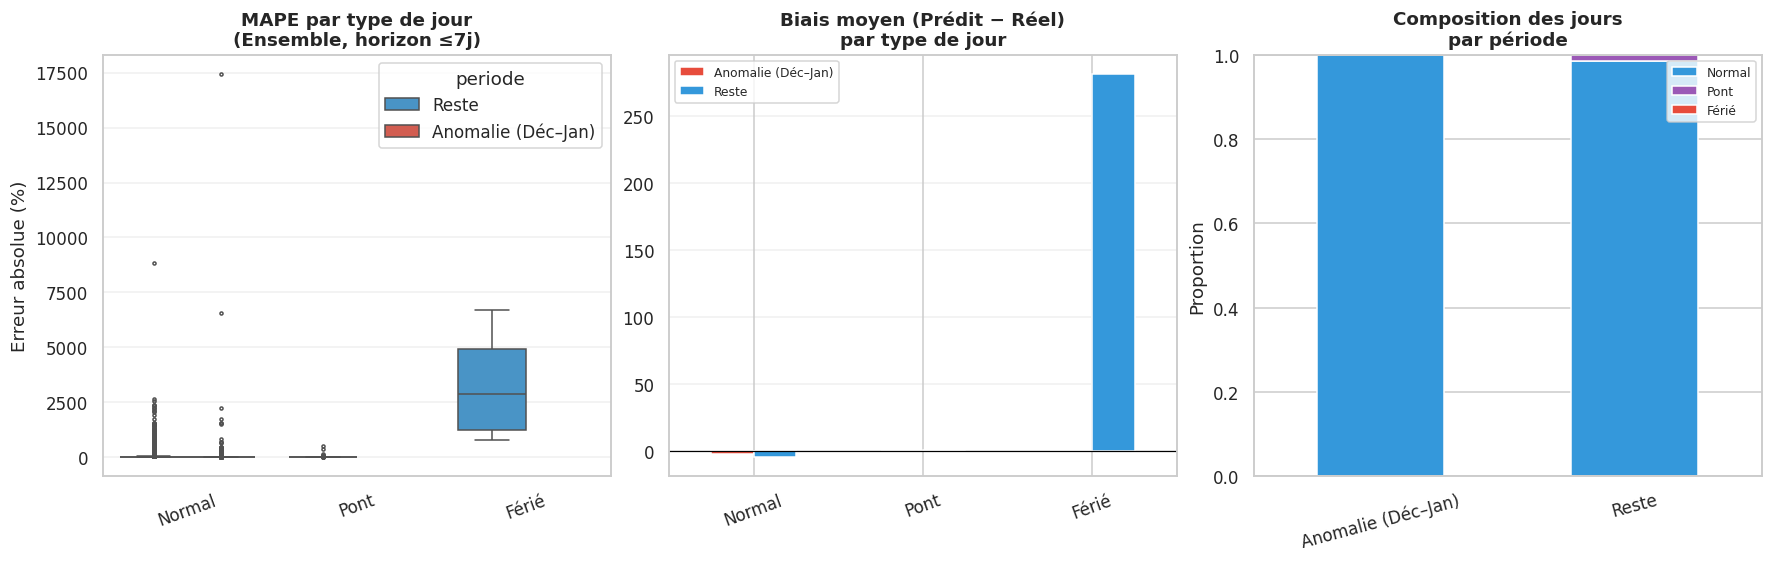


MAPE moyen par type de jour et période :
day_type             Férié  Normal  Pont
periode                                 
Anomalie (Déc–Jan)     NaN    19.3   NaN
Reste               3317.8    25.4  14.0


In [7]:
ens7 = df_binned[
    (df_binned['model'] == 'Ensemble') &
    (df_binned['horizon_bin'] == '≤7j') &
    (df_binned['effectif_reel'] > 0)
].dropna(subset=['effectif_reel']).copy()

ens7['abs_err_pct'] = np.abs(ens7['effectif_reel'] - ens7['prediction']) / ens7['effectif_reel'] * 100
ens7['biais']       = ens7['prediction'] - ens7['effectif_reel']

TYPE_ORDER = ['Normal', 'Vacances', 'Pont', 'Férié', 'Fermé habituellement']
type_order = [t for t in TYPE_ORDER if t in ens7['day_type'].unique()]
palette    = {'Normal':'#3498DB','Vacances':'#E67E22','Pont':'#9B59B6',
              'Férié':'#E74C3C','Fermé habituellement':'#7F8C8D'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

# 1. MAPE par type de jour × période
sns.boxplot(
    data=ens7, x='day_type', y='abs_err_pct', hue='periode',
    order=type_order, ax=axes[0],
    palette={'Anomalie (Déc–Jan)':'#E74C3C', 'Reste':'#3498DB'},
    flierprops={'markersize': 2}
)
axes[0].set_title('MAPE par type de jour\n(Ensemble, horizon ≤7j)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Erreur absolue (%)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)

# 2. Biais moyen par type de jour
biais_type = ens7.groupby(['day_type','periode'])['biais'].mean().reset_index()
biais_pivot = biais_type.pivot(index='day_type', columns='periode', values='biais').reindex(type_order)
biais_pivot.plot(kind='bar', ax=axes[1], color=['#E74C3C','#3498DB'])
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Biais moyen (Prédit − Réel)\npar type de jour', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='', fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

# 3. Proportion de jours "spéciaux" dans la période anomalie vs reste
prop = ens7.drop_duplicates(['target_date','uai']).groupby('periode')['day_type'].value_counts(normalize=True).unstack(fill_value=0)
prop[type_order].plot(kind='bar', stacked=True, ax=axes[2],
                      color=[palette.get(t,'grey') for t in type_order])
axes[2].set_title('Composition des jours\npar période', fontweight='bold')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=15)
axes[2].set_ylabel('Proportion')
axes[2].legend(fontsize=8, loc='upper right')

plt.show()

print("\nMAPE moyen par type de jour et période :")
print(ens7.groupby(['periode','day_type'])['abs_err_pct'].mean().round(1).unstack(fill_value=np.nan).to_string())

## 7. Zoom vacances de Noël — Comparaison features vs effectif réel

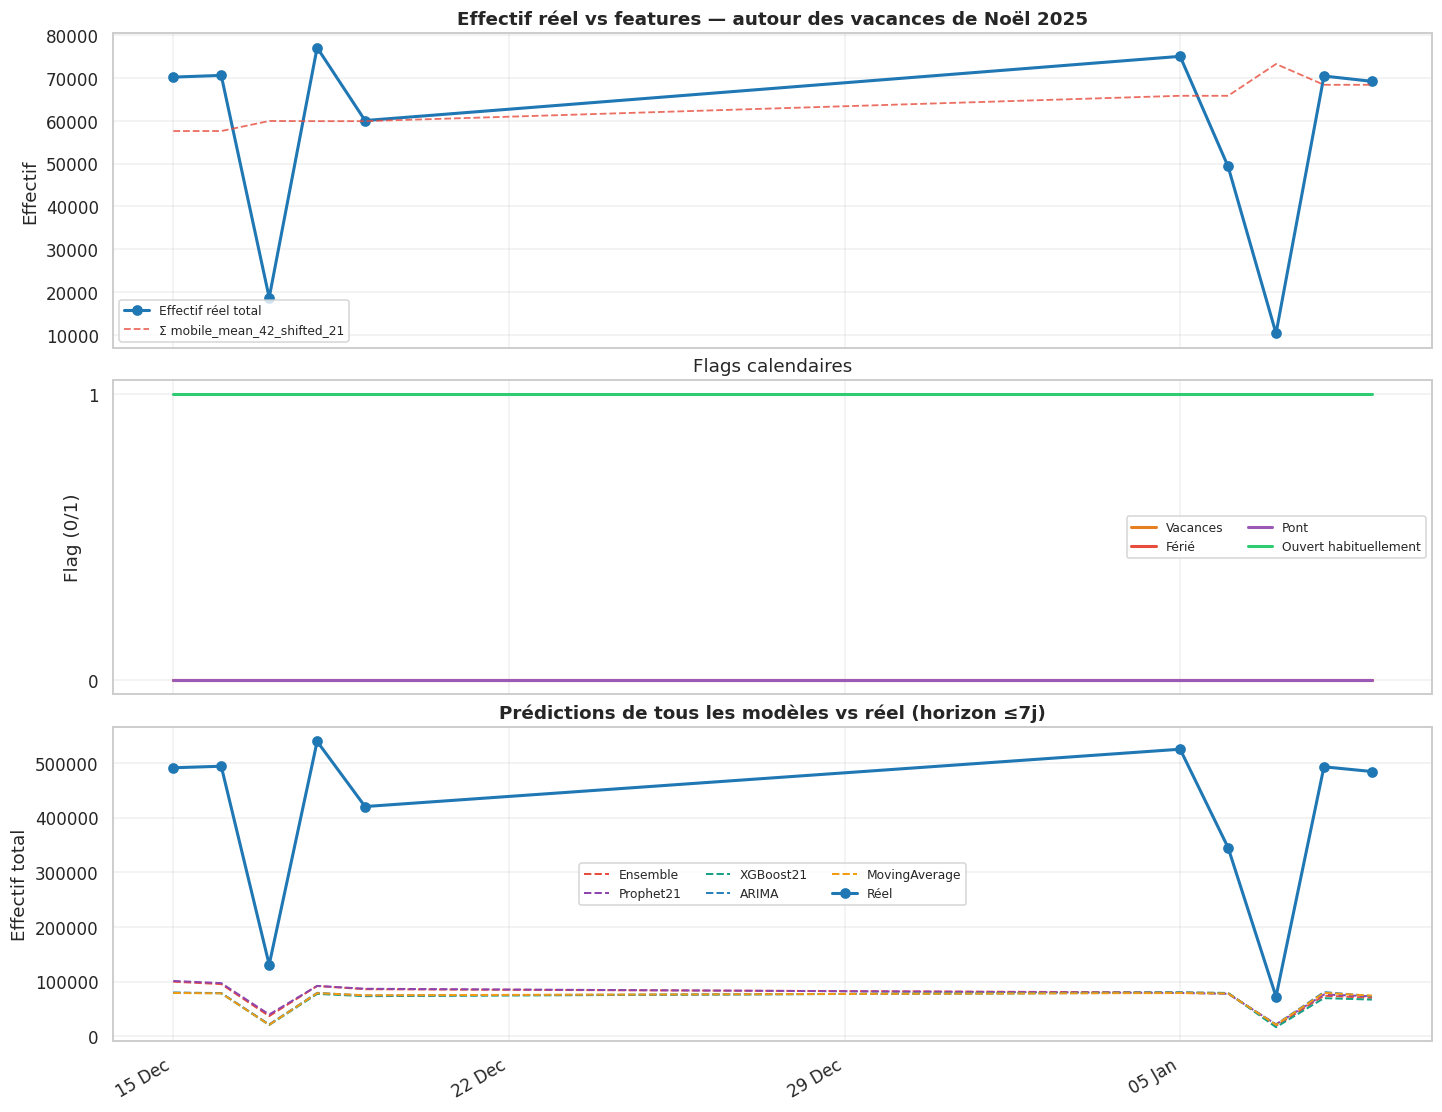

In [8]:
# Fenêtre autour des vacances de Noël 2025
noel_start = pd.Timestamp('2025-12-15')
noel_end   = pd.Timestamp('2026-01-10')

df_noel = df_binned[
    (df_binned['target_date'] >= noel_start) &
    (df_binned['target_date'] <= noel_end)
].drop_duplicates(['target_date', 'uai']).sort_values('target_date')

# Agréger par jour
daily_noel = df_noel.groupby('target_date', as_index=False).agg(
    is_holyday=('is_holyday', 'max'),
    is_ferie=('is_ferie', 'max'),
    is_bridge=('is_bridge', 'max'),
    is_day_usually_open=('is_day_usually_open', 'max'),
    effectif_reel_sum=('effectif_reel', 'sum'),
    mobile_mean_42=('mobile_mean_42_shifted_21', 'mean'),
    daily_mobile=('daily_mobile_mean_8_shifted_4', 'mean'),
).sort_values('target_date')
daily_noel.loc[daily_noel['effectif_reel_sum'] == 0, 'effectif_reel_sum'] = np.nan

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True, constrained_layout=True)

# Axe 1 : effectif réel + features
ax1 = axes[0]
real_noel = daily_noel.dropna(subset=['effectif_reel_sum'])
ax1.plot(real_noel['target_date'], real_noel['effectif_reel_sum'],
         'o-', color='#1F77B4', lw=2, label='Effectif réel total')
if 'mobile_mean_42' in daily_noel.columns:
    scale = real_noel['effectif_reel_sum'].mean() / daily_noel['mobile_mean_42'].mean() if daily_noel['mobile_mean_42'].mean() > 0 else 1
    ax1.plot(daily_noel['target_date'], daily_noel['mobile_mean_42'] * len(df_noel['uai'].unique()),
             '--', color='#E74C3C', lw=1.2, alpha=0.8, label='Σ mobile_mean_42_shifted_21')
ax1.set_ylabel('Effectif')
ax1.set_title('Effectif réel vs features — autour des vacances de Noël 2025', fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Axe 2 : flags is_holyday, is_ferie, is_bridge
ax2 = axes[1]
for col, color, lbl in [('is_holyday','#E67E22','Vacances'),
                         ('is_ferie','#E74C3C','Férié'),
                         ('is_bridge','#9B59B6','Pont'),
                         ('is_day_usually_open','#2ECC71','Ouvert habituellement')]:
    if col in daily_noel.columns:
        ax2.step(daily_noel['target_date'], daily_noel[col],
                 where='mid', color=color, lw=2, label=lbl)
ax2.set_ylabel('Flag (0/1)')
ax2.set_title('Flags calendaires')
ax2.legend(fontsize=8, ncol=2)
ax2.set_yticks([0, 1])
ax2.grid(alpha=0.3)

# Axe 3 : Prédictions des différents modèles
ax3 = axes[2]
models_zoom = [m for m in ['Ensemble','Prophet21','XGBoost21','ARIMA','MovingAverage']
               if m in df_binned['model'].unique()]
zoom_colors = {'Ensemble':'#E74C3C','Prophet21':'#8E44AD','XGBoost21':'#16A085',
               'ARIMA':'#2980B9','MovingAverage':'#F39C12'}

for m in models_zoom:
    sub_m = df_binned[
        (df_binned['model'] == m) &
        (df_binned['target_date'] >= noel_start) &
        (df_binned['target_date'] <= noel_end) &
        (df_binned['horizon_bin'] == '≤7j')
    ].groupby('target_date')['prediction'].sum().reset_index()
    ax3.plot(sub_m['target_date'], sub_m['prediction'],
             '--', color=zoom_colors.get(m,'grey'), lw=1.3, label=m)

real_zoom = df_binned[
    (df_binned['target_date'] >= noel_start) &
    (df_binned['target_date'] <= noel_end) &
    (df_binned['horizon_bin'] == '≤7j') &
    (df_binned['effectif_reel'] > 0)
].dropna(subset=['effectif_reel']).groupby('target_date')['effectif_reel'].sum().reset_index()

ax3.plot(real_zoom['target_date'], real_zoom['effectif_reel'],
         'o-', color='#1F77B4', lw=2, label='Réel')
ax3.set_ylabel('Effectif total')
ax3.set_title('Prédictions de tous les modèles vs réel (horizon ≤7j)', fontweight='bold')
ax3.legend(fontsize=8, ncol=3)
ax3.grid(alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.show()

## 8. Features mal calibrées ? Comparaison valeur feature vs effectif réel

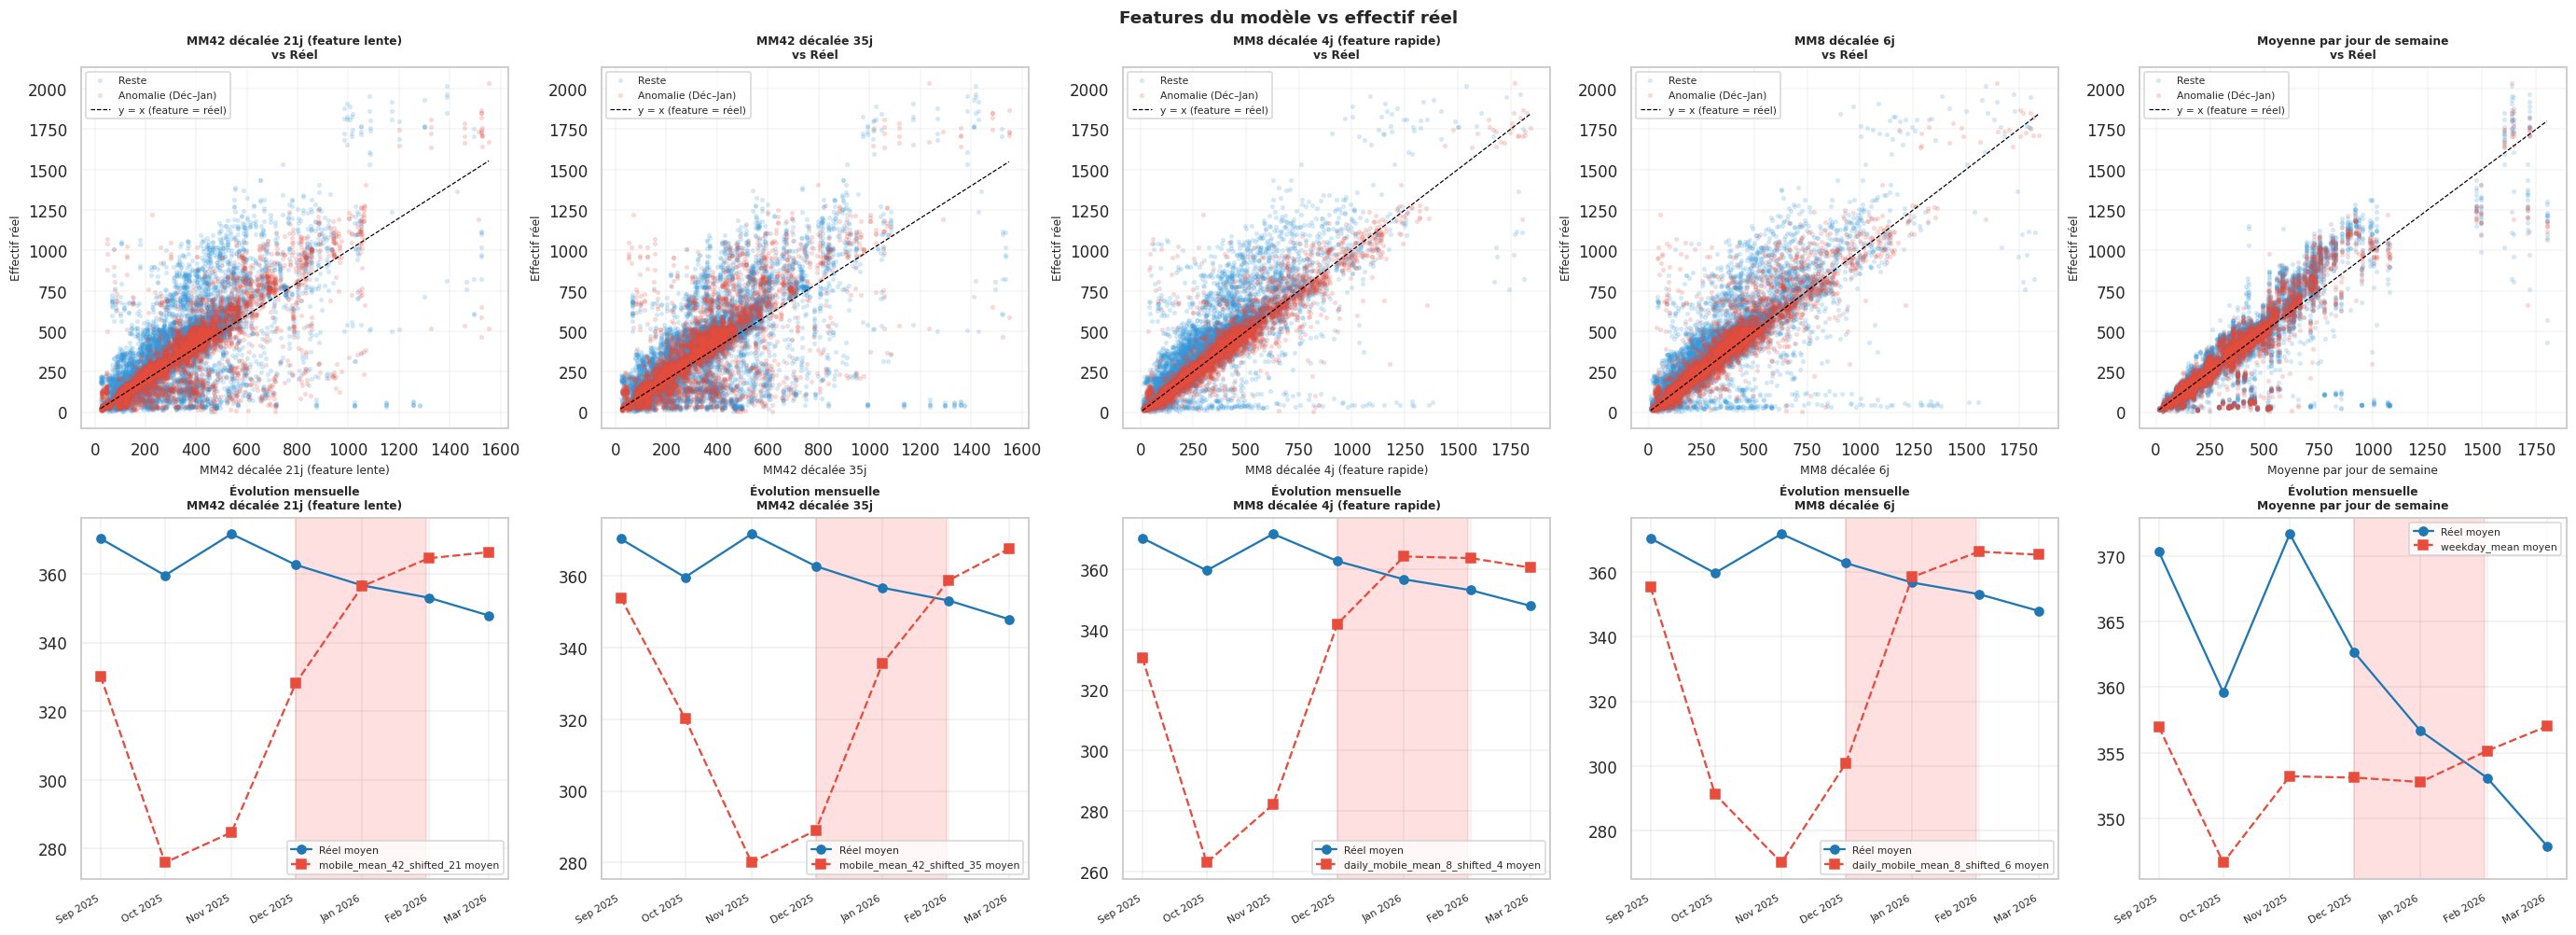

In [9]:
feat_cols = [
    ('mobile_mean_42_shifted_21',    'MM42 décalée 21j (feature lente)'),
    ('mobile_mean_42_shifted_35',    'MM42 décalée 35j'),
    ('daily_mobile_mean_8_shifted_4','MM8 décalée 4j (feature rapide)'),
    ('daily_mobile_mean_8_shifted_6','MM8 décalée 6j'),
    ('weekday_mean',                 'Moyenne par jour de semaine'),
]
available = [(c, l) for c, l in feat_cols if c in df_binned.columns]

ens7_feat = ens7[ens7['effectif_reel'] > 0].dropna(subset=['effectif_reel']).copy()

n = len(available)
if n == 0:
    print("Aucune colonne de feature disponible dans les données binnées.")
else:
    fig, axes = plt.subplots(2, n, figsize=(5 * n, 9), constrained_layout=True)
    if n == 1: axes = axes.reshape(2, 1)

    for j, (col, lbl) in enumerate(available):
        sub_col = ens7_feat.dropna(subset=[col])
        # Ligne 1 : feature vs effectif_reel (scatter) par période
        for prd, color in [('Reste','#3498DB'), ('Anomalie (Déc–Jan)','#E74C3C')]:
            s = sub_col[sub_col['periode'] == prd]
            axes[0, j].scatter(s[col], s['effectif_reel'], alpha=0.15, s=6, color=color, label=prd)
        axes[0, j].plot(
            [sub_col[col].min(), sub_col[col].max()],
            [sub_col[col].min(), sub_col[col].max()],
            'k--', lw=0.8, label='y = x (feature = réel)'
        )
        axes[0, j].set_xlabel(lbl, fontsize=8)
        axes[0, j].set_ylabel('Effectif réel', fontsize=8)
        axes[0, j].set_title(f'{lbl}\nvs Réel', fontsize=8, fontweight='bold')
        axes[0, j].legend(fontsize=7)
        axes[0, j].grid(alpha=0.2)

        # Ligne 2 : évolution mensuelle de feature vs effectif_reel
        monthly = sub_col.groupby([sub_col['target_date'].dt.to_period('M'), 'periode']).agg(
            feat_mean=(col, 'mean'),
            real_mean=('effectif_reel', 'mean')
        ).reset_index()
        monthly['month_dt'] = monthly['target_date'].dt.to_timestamp()
        axes[1, j].plot(monthly['month_dt'], monthly['real_mean'], 'o-', color='#1F77B4', lw=1.5, label='Réel moyen')
        axes[1, j].plot(monthly['month_dt'], monthly['feat_mean'], 's--', color='#E74C3C', lw=1.5, label=f'{col} moyen')
        axes[1, j].axvspan(ANOMALY_START, ANOMALY_END, alpha=0.12, color='red')
        axes[1, j].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        axes[1, j].xaxis.set_major_locator(mdates.MonthLocator())
        plt.setp(axes[1, j].xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)
        axes[1, j].set_title(f'Évolution mensuelle\n{lbl}', fontsize=8, fontweight='bold')
        axes[1, j].legend(fontsize=7)
        axes[1, j].grid(alpha=0.3)

    plt.suptitle('Features du modèle vs effectif réel', fontsize=12, fontweight='bold')
    plt.show()

## 9. Établissements les plus touchés sur la période

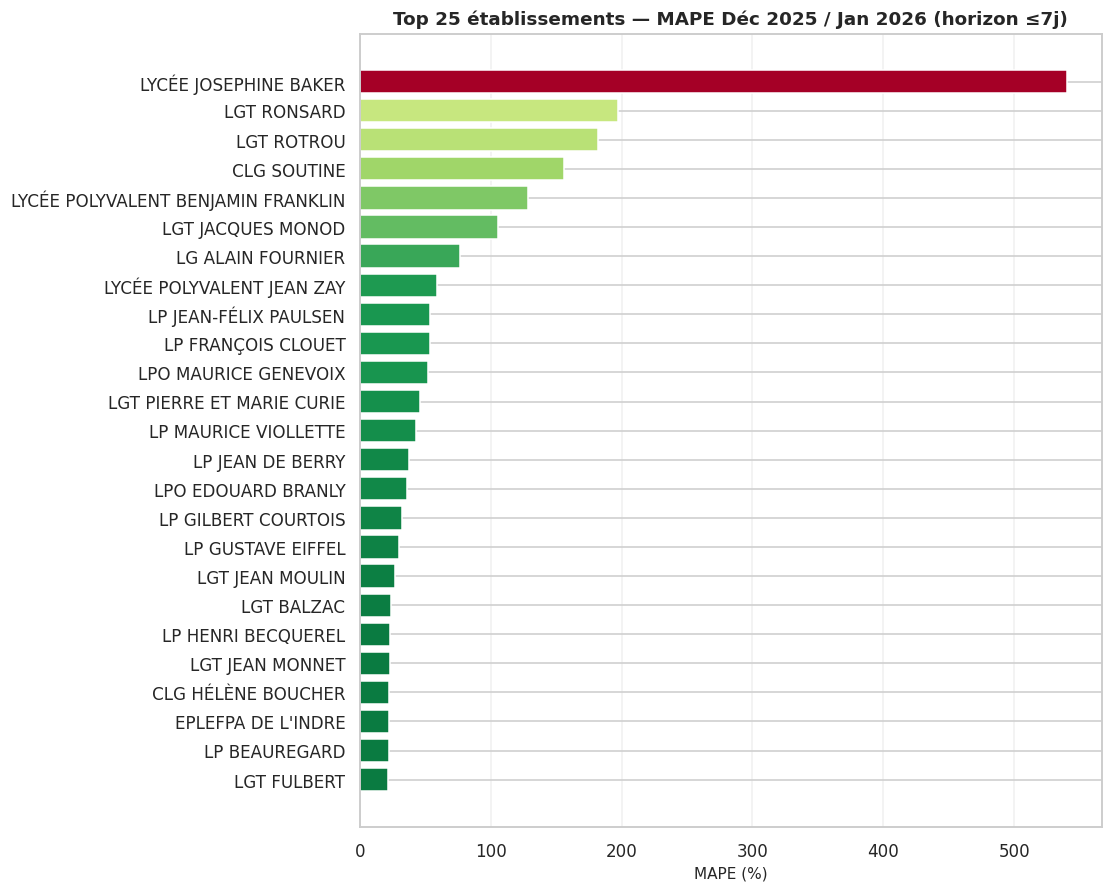

Nb établissements avec Ratio P/R > 1.5 : 6
Nb établissements avec Ratio P/R > 2   : 5

Top 15 établissements (MAPE) :


,nometabs,ville,MAPE (%),Biais moyen,Ratio P/R,N jours
105,LYCÉE JOSEPHINE BAKER,HANCHES,540.0,34.2,6.3,35.0
148,LGT RONSARD,VENDOME,197.2,1.1,2.9,35.0
61,LGT ROTROU,DREUX,182.2,21.8,2.2,35.0
101,CLG SOUTINE,SAINT-PREST,156.3,5.1,2.5,27.0
176,LYCÉE POLYVALENT BENJAMIN FRANKLIN,ORLEANS,128.7,73.6,2.3,35.0
185,LGT JACQUES MONOD,SAINT-JEAN-DE-BRAYE,105.6,-17.6,1.9,34.0
2,LG ALAIN FOURNIER,BOURGES,76.8,-6.9,1.4,33.0
175,LYCÉE POLYVALENT JEAN ZAY,ORLEANS,58.6,15.4,1.5,35.0
74,LP JEAN-FÉLIX PAULSEN,CHATEAUDUN,53.5,-21.7,1.0,35.0
119,LP FRANÇOIS CLOUET,TOURS,53.5,4.7,1.5,35.0


In [10]:
df_anom = ens7[
    (ens7['target_date'] >= ANOMALY_START) &
    (ens7['target_date'] <= ANOMALY_END)
].copy()

etab_stats = df_anom.groupby('uai').apply(
    lambda g: pd.Series({
        'MAPE (%)':    mape(g['effectif_reel'], g['prediction']),
        'Biais moyen': (g['prediction'] - g['effectif_reel']).mean(),
        'Ratio P/R':   (g['prediction'] / g['effectif_reel'].replace(0, np.nan)).mean(),
        'N jours':     len(g),
    })
).reset_index()

etab_stats = etab_stats.merge(df_etab[['uai','nometabs','ville']], on='uai', how='left')
etab_stats['nometabs'] = etab_stats['nometabs'].fillna(etab_stats['uai'])
etab_stats = etab_stats.sort_values('MAPE (%)', ascending=False)

top25 = etab_stats.head(25)

fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
bars = ax.barh(top25['nometabs'], top25['MAPE (%)'],
               color=plt.cm.RdYlGn_r(top25['MAPE (%)'] / top25['MAPE (%)'].max()))
ax.set_xlabel('MAPE (%)', fontsize=10)
ax.set_title('Top 25 établissements — MAPE Déc 2025 / Jan 2026 (horizon ≤7j)', fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.show()

print(f"Nb établissements avec Ratio P/R > 1.5 : {(etab_stats['Ratio P/R'] > 1.5).sum()}")
print(f"Nb établissements avec Ratio P/R > 2   : {(etab_stats['Ratio P/R'] > 2.0).sum()}")
print("\nTop 15 établissements (MAPE) :")
display(etab_stats[['nometabs','ville','MAPE (%)','Biais moyen','Ratio P/R','N jours']].head(15).round(1))

## 10. MAPE mensuel — Évolution sur toute la période de contexte

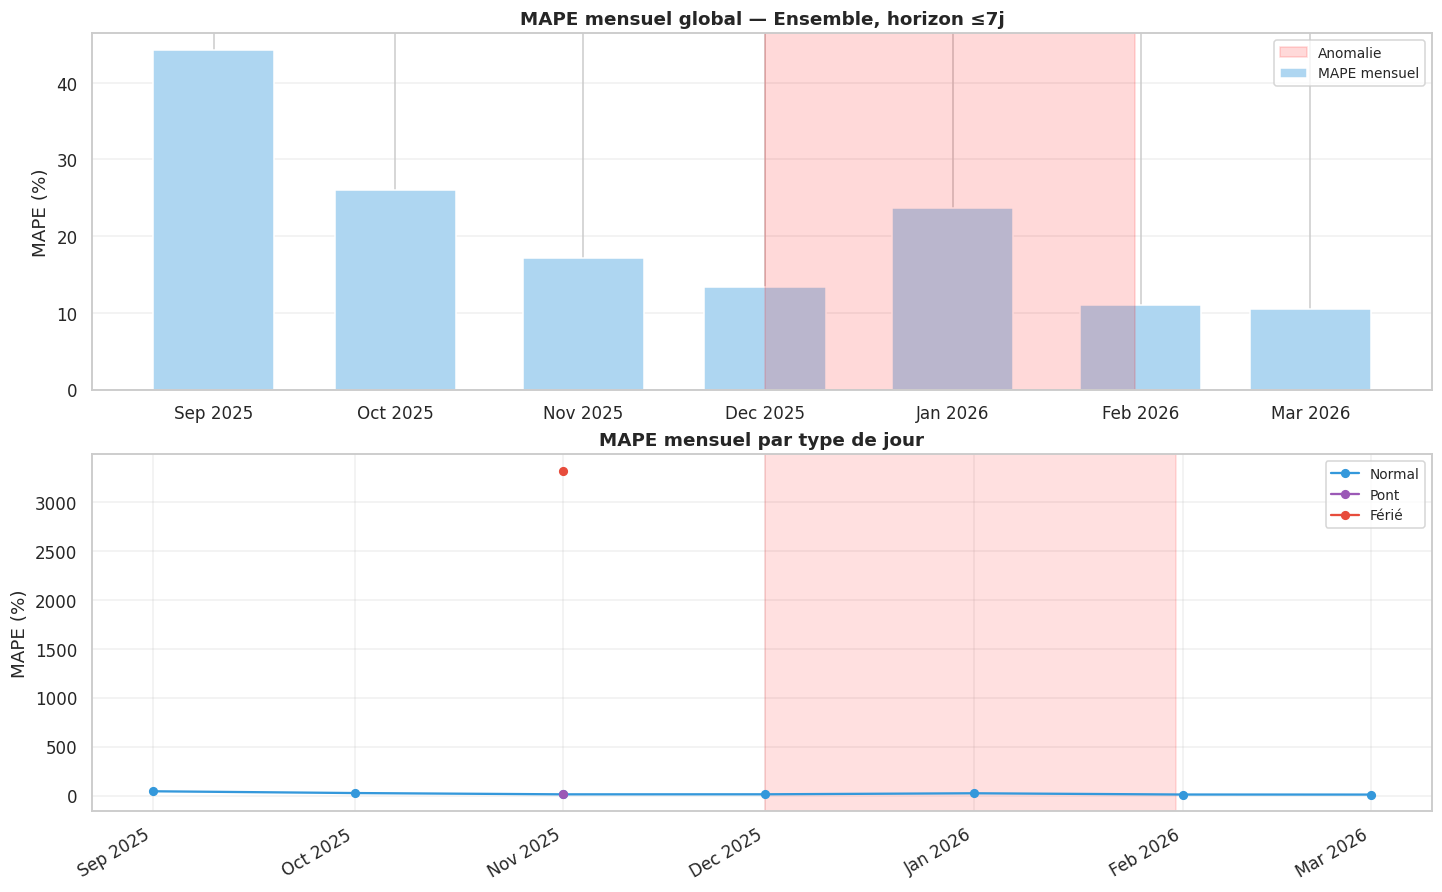

In [11]:
ens7['month']        = ens7['target_date'].dt.to_period('M')
ens7['abs_err_pct']  = np.abs(ens7['effectif_reel'] - ens7['prediction']) / ens7['effectif_reel'] * 100

monthly_by_type = (
    ens7.groupby(['month', 'day_type'])['abs_err_pct']
    .mean()
    .reset_index(name='mape')
)
monthly_by_type['month_dt'] = monthly_by_type['month'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), constrained_layout=True)

# Axe 1 : MAPE mensuel global
monthly_global = ens7.groupby('month')['abs_err_pct'].mean().reset_index(name='mape')
monthly_global['month_dt'] = monthly_global['month'].dt.to_timestamp()
axes[0].bar(monthly_global['month_dt'], monthly_global['mape'],
            color='#AED6F1', width=20, label='MAPE mensuel')
axes[0].axvspan(ANOMALY_START, ANOMALY_END, alpha=0.15, color='red', label='Anomalie')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_title('MAPE mensuel global — Ensemble, horizon ≤7j', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Axe 2 : MAPE mensuel par type de jour
for dtype in type_order:
    sub_t = monthly_by_type[monthly_by_type['day_type'] == dtype]
    if not sub_t.empty:
        axes[1].plot(sub_t['month_dt'], sub_t['mape'],
                     marker='o', markersize=5, label=dtype,
                     color=palette.get(dtype, 'grey'))
axes[1].axvspan(ANOMALY_START, ANOMALY_END, alpha=0.12, color='red')
axes[1].set_ylabel('MAPE (%)')
axes[1].set_title('MAPE mensuel par type de jour', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.show()

## 11. Diagnostic — Décomposition de la somme journalière

La somme journalière = **N établissements** × **valeur moyenne par établissement**.

Si la somme augmente en décembre sans que les établissements individuels semblent gonflés, c'est que **N augmente** : plus d'établissements contribuent à la somme (par ex. parce que les prédictions à long horizon pour décembre n'existaient pas encore en septembre).

On décompose ici la somme pour identifier la vraie cause.

In [12]:
# Population avec prédiction vs population avec effectif réel — par target_date
ens_raw = df[df['model'] == 'Ensemble'].copy()
# Garder min horizon per (target_date, uai, service) pour ne pas multiplier les lignes
ens_min = (
    ens_raw.sort_values('horizon')
    .groupby(['target_date', 'uai', 'service'], as_index=False)
    .first()
)

pop_daily = ens_min.groupby('target_date', as_index=False).agg(
    n_avec_pred  = ('prediction',    lambda x: (x.notna() & (x > 0)).sum()),
    n_avec_reel  = ('effectif_reel', lambda x: (x.notna() & (x > 0)).sum()),
    sum_pred_all = ('prediction',    'sum'),
    sum_pred_commun = ('prediction', lambda x: x[ens_min.loc[x.index, 'effectif_reel'] > 0].sum()),
    sum_reel     = ('effectif_reel', lambda x: x[x > 0].sum()),
).sort_values('target_date')

pop_daily['pct_couverture'] = (pop_daily['n_avec_reel'] / pop_daily['n_avec_pred'] * 100).round(1)
pop_daily['ratio_pred_all_vs_reel'] = (pop_daily['sum_pred_all'] / pop_daily['sum_reel'].replace(0, float('nan'))).round(2)
pop_daily['ratio_pred_commun_vs_reel'] = (pop_daily['sum_pred_commun'] / pop_daily['sum_reel'].replace(0, float('nan'))).round(2)

# Résumé par période
pop_daily['periode'] = np.where(
    (pop_daily['target_date'] >= ANOMALY_START) & (pop_daily['target_date'] <= ANOMALY_END),
    'Déc–Jan (anomalie)', 'Reste'
)
print('=== Population moyenne par période ===')
print(pop_daily.groupby('periode')[[
    'n_avec_pred','n_avec_reel','pct_couverture',
    'ratio_pred_all_vs_reel','ratio_pred_commun_vs_reel'
]].mean().round(2).to_string())

print('\n=> ratio_pred_all_vs_reel > 1 + pct_couverture < 100% → somme prédite gonflée par les étab. sans réel')
print('=> ratio_pred_commun_vs_reel > 1                   → prédictions elles-mêmes trop hautes (vraie erreur modèle)')


=== Population moyenne par période ===
                    n_avec_pred  n_avec_reel  pct_couverture  ratio_pred_all_vs_reel  ratio_pred_commun_vs_reel
periode                                                                                                        
Déc–Jan (anomalie)       180.11       165.60           91.83                    1.43                       1.00
Reste                    162.08       114.23           70.25                   16.23                       1.23

=> ratio_pred_all_vs_reel > 1 + pct_couverture < 100% → somme prédite gonflée par les étab. sans réel
=> ratio_pred_commun_vs_reel > 1                   → prédictions elles-mêmes trop hautes (vraie erreur modèle)


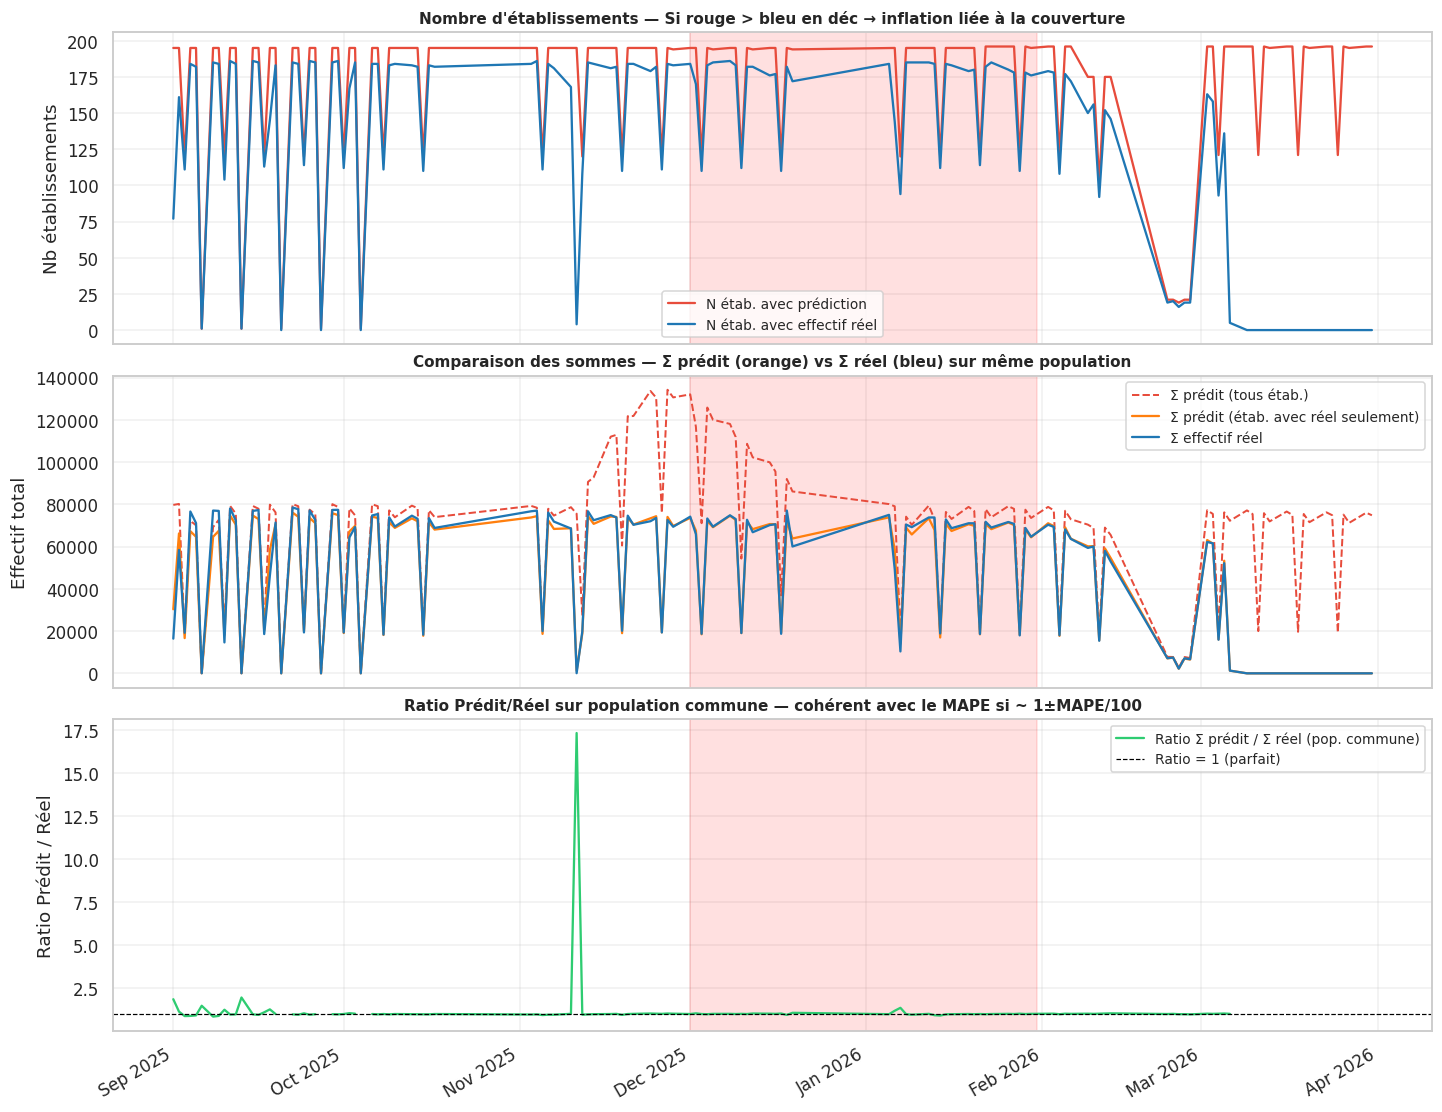

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True, constrained_layout=True)

# Axe 1 : Nb établissements avec prédiction vs avec réel
axes[0].plot(pop_daily['target_date'], pop_daily['n_avec_pred'],
             color='#E74C3C', lw=1.5, label='N étab. avec prédiction')
axes[0].plot(pop_daily['target_date'], pop_daily['n_avec_reel'],
             color='#1F77B4', lw=1.5, label='N étab. avec effectif réel')
axes[0].axvspan(ANOMALY_START, ANOMALY_END, alpha=0.12, color='red')
axes[0].set_ylabel('Nb établissements')
axes[0].set_title(
    'Nombre d\'établissements — Si rouge > bleu en déc → inflation liée à la couverture',
    fontweight='bold', fontsize=10
)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Axe 2 : Somme prédite ALL vs somme prédite sur pop commune vs réel
axes[1].plot(pop_daily['target_date'], pop_daily['sum_pred_all'],
             '--', color='#E74C3C', lw=1.3, label='Σ prédit (tous étab.)')
axes[1].plot(pop_daily['target_date'], pop_daily['sum_pred_commun'],
             color='#FF7F0E', lw=1.5, label='Σ prédit (étab. avec réel seulement)')
axes[1].plot(pop_daily['target_date'], pop_daily['sum_reel'],
             color='#1F77B4', lw=1.5, label='Σ effectif réel')
axes[1].axvspan(ANOMALY_START, ANOMALY_END, alpha=0.12, color='red')
axes[1].set_ylabel('Effectif total')
axes[1].set_title(
    'Comparaison des sommes — Σ prédit (orange) vs Σ réel (bleu) sur même population',
    fontweight='bold', fontsize=10
)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Axe 3 : Ratio prédit/réel sur population commune — c'est le vrai ratio à comparer au MAPE
axes[2].plot(pop_daily['target_date'], pop_daily['ratio_pred_commun_vs_reel'],
             color='#2ECC71', lw=1.5, label='Ratio Σ prédit / Σ réel (pop. commune)')
axes[2].axhline(1.0, color='black', lw=0.8, linestyle='--', label='Ratio = 1 (parfait)')
axes[2].axvspan(ANOMALY_START, ANOMALY_END, alpha=0.12, color='red')
axes[2].set_ylabel('Ratio Prédit / Réel')
axes[2].set_title(
    'Ratio Prédit/Réel sur population commune — cohérent avec le MAPE si ~ 1±MAPE/100',
    fontweight='bold', fontsize=10
)
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.show()


In [14]:
# Construire les données binnées sans filtre de dates pour avoir tout le contexte
df_binned_ctx = build_binned(df)   # df = données chargées depuis Trino
ens_binned = df_binned_ctx[df_binned_ctx['model'] == 'Ensemble'].copy()

# Pour chaque (target_date, horizon_bin), compter le nb d'établissements et calculer la moyenne
def decompose_sum(df_in, bin_label):
    sub = df_in[df_in['horizon_bin'] == bin_label].copy()
    # Agréger services par (target_date, uai)
    per_uai = sub.groupby(['target_date', 'uai'], as_index=False).agg(
        prediction_uai=('prediction', 'sum'),
    )
    # Puis agréger par target_date
    daily = per_uai.groupby('target_date', as_index=False).agg(
        n_etab=('uai', 'count'),
        pred_total=('prediction_uai', 'sum'),
        pred_moy=('prediction_uai', 'mean'),
    ).sort_values('target_date')
    daily['bin'] = bin_label
    return daily

parts = [decompose_sum(ens_binned, b) for b in BIN_ORDER]
df_decomp = pd.concat(parts, ignore_index=True)

print('Nombre moyen d\'établissements par bin et par période :')
df_decomp['periode'] = np.where(
    (df_decomp['target_date'] >= ANOMALY_START) & (df_decomp['target_date'] <= ANOMALY_END),
    'Déc–Jan (anomalie)', 'Reste'
)
print(df_decomp.groupby(['bin','periode'])[['n_etab','pred_moy']].mean().round(1).to_string())


Nombre moyen d'établissements par bin et par période :
                         n_etab  pred_moy
bin  periode                             
>21j Déc–Jan (anomalie)   176.2     386.1
     Reste                156.5     335.9
≤14j Déc–Jan (anomalie)   180.1     414.4
     Reste                169.1     371.5
≤21j Déc–Jan (anomalie)   180.0     401.3
     Reste                167.3     362.1
≤7j  Déc–Jan (anomalie)   180.2     427.7
     Reste                170.9     378.7


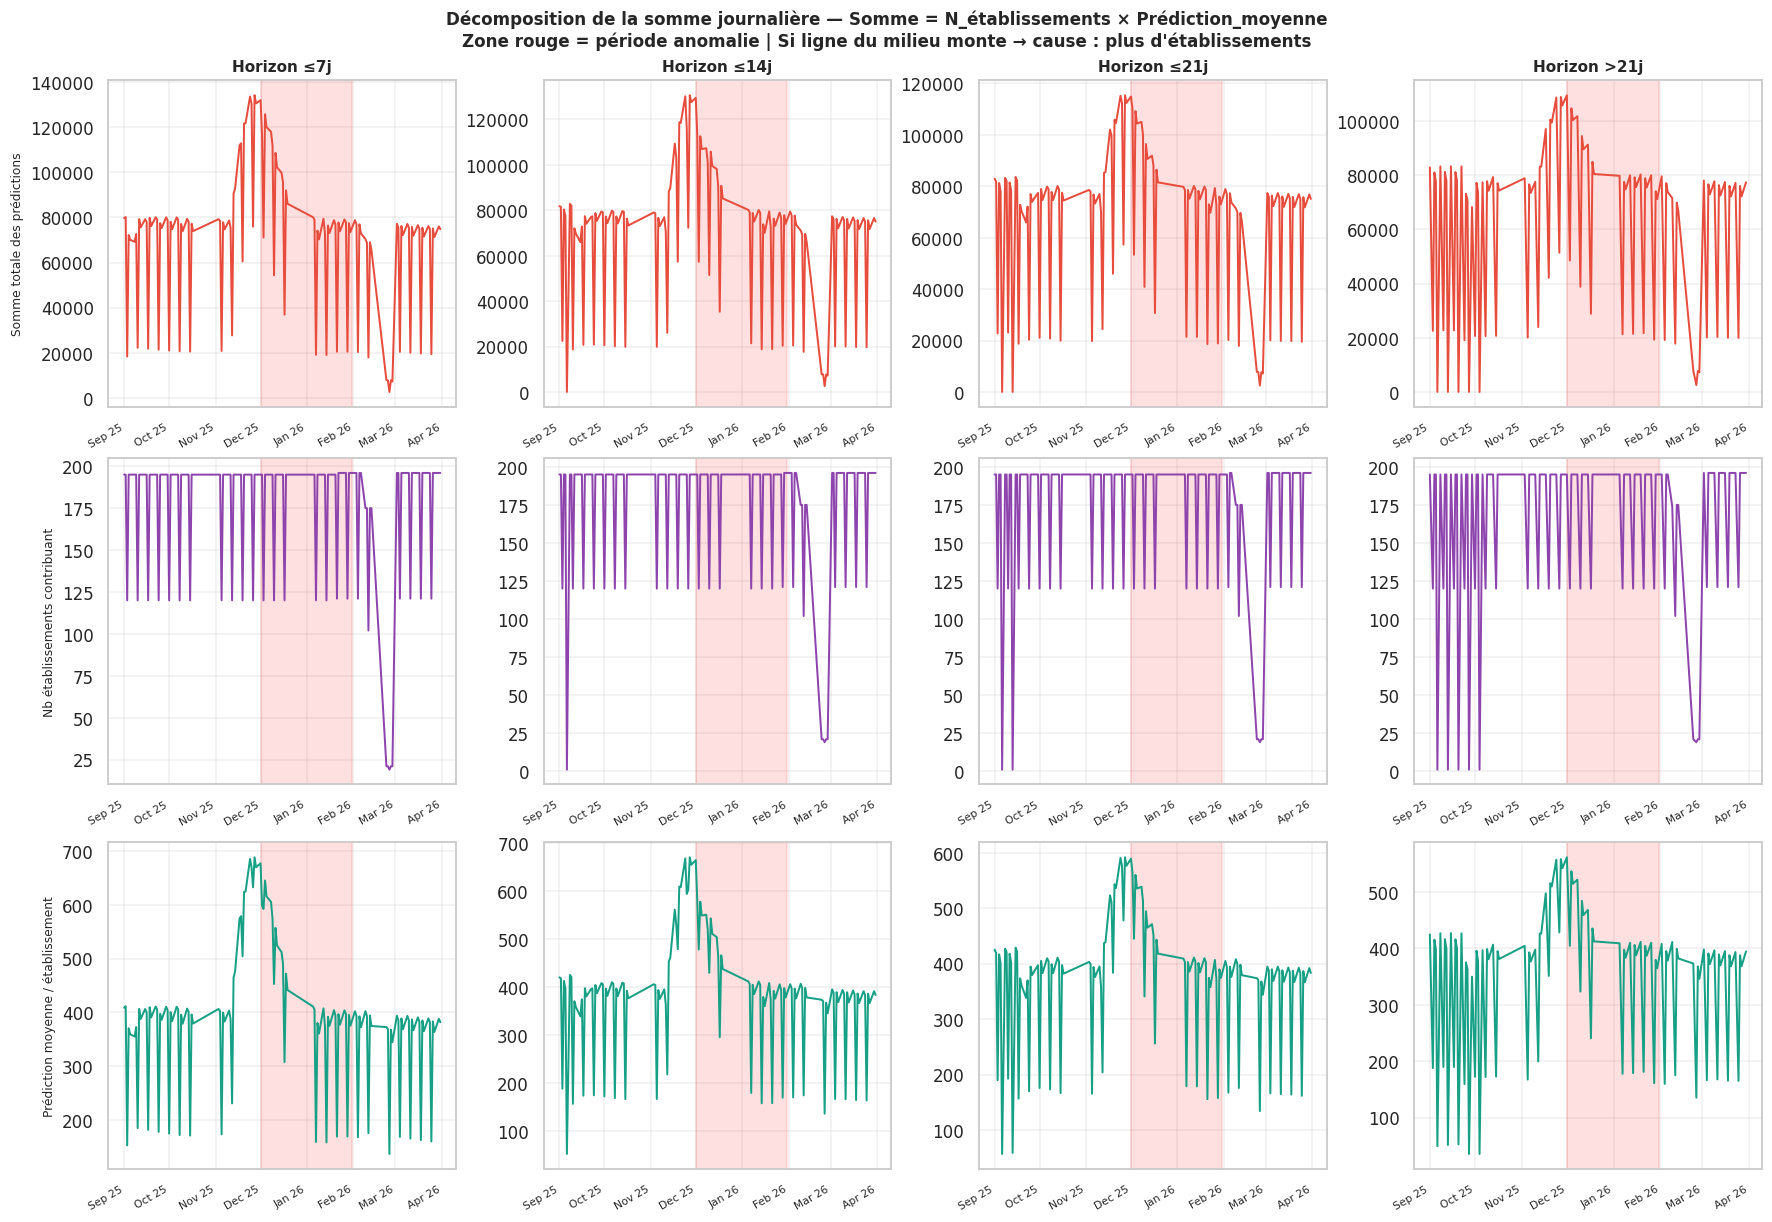

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, len(BIN_ORDER), figsize=(16, 11), constrained_layout=True)

row_titles = [
    'Somme totale des prédictions',
    'Nb établissements contribuant',
    'Prédiction moyenne / établissement',
]

for j, b in enumerate(BIN_ORDER):
    sub = df_decomp[df_decomp['bin'] == b].sort_values('target_date')

    # Ligne 0 : somme totale
    axes[0, j].plot(sub['target_date'], sub['pred_total'], color='#E74C3C', lw=1.3)
    axes[0, j].axvspan(ANOMALY_START, ANOMALY_END, alpha=0.12, color='red')
    axes[0, j].set_title(f'Horizon {b}', fontweight='bold', fontsize=10)
    if j == 0: axes[0, j].set_ylabel(row_titles[0], fontsize=8)
    axes[0, j].grid(alpha=0.3)

    # Ligne 1 : nb établissements
    axes[1, j].plot(sub['target_date'], sub['n_etab'], color='#8E44AD', lw=1.3)
    axes[1, j].axvspan(ANOMALY_START, ANOMALY_END, alpha=0.12, color='red')
    if j == 0: axes[1, j].set_ylabel(row_titles[1], fontsize=8)
    axes[1, j].grid(alpha=0.3)

    # Ligne 2 : moyenne par établissement
    axes[2, j].plot(sub['target_date'], sub['pred_moy'], color='#16A085', lw=1.3)
    axes[2, j].axvspan(ANOMALY_START, ANOMALY_END, alpha=0.12, color='red')
    if j == 0: axes[2, j].set_ylabel(row_titles[2], fontsize=8)
    axes[2, j].grid(alpha=0.3)

    for row in range(3):
        axes[row, j].xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
        axes[row, j].xaxis.set_major_locator(mdates.MonthLocator())
        plt.setp(axes[row, j].xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)

fig.suptitle(
    'Décomposition de la somme journalière — Somme = N_établissements × Prédiction_moyenne\n'
    'Zone rouge = période anomalie | Si ligne du milieu monte → cause : plus d\'établissements',
    fontsize=11, fontweight='bold'
)
plt.show()


In [16]:
# --- Focus sur le bin ≤7j : liste des établissements présents par mois ---

sub7 = df_decomp[df_decomp['bin'] == '≤7j'].copy()
sub7['month'] = sub7['target_date'].dt.to_period('M')

monthly_count = sub7.groupby('month').agg(
    n_etab_moy=('n_etab', 'mean'),
    pred_total_moy=('pred_total', 'mean'),
    pred_moy_moy=('pred_moy', 'mean'),
).round(1)
print('=== Horizon ≤7j — Moyennes mensuelles ===')
print(monthly_count.to_string())
print()

# Identifier les établissements qui apparaissent UNIQUEMENT en décembre-janvier
ens7_detail = ens_binned[
    (ens_binned['horizon_bin'] == '≤7j') &
    (ens_binned['effectif_reel'].isna() | (ens_binned['effectif_reel'] == 0))
].copy()

# Établissements avec prédictions mais sans effectif_reel sur toute la période
uais_no_real = ens7_detail['uai'].unique()
uais_with_real = ens_binned[
    (ens_binned['horizon_bin'] == '≤7j') &
    (ens_binned['effectif_reel'] > 0)
]['uai'].unique()
uais_only_pred = set(uais_no_real) - set(uais_with_real)
print(f'Établissements avec prédictions mais jamais d\'effectif réel : {len(uais_only_pred)}')
if uais_only_pred:
    df_ghost = pd.DataFrame({'uai': list(uais_only_pred)}).merge(df_etab, on='uai', how='left')
    print('Exemples :')
    print(df_ghost[['uai','nometabs','ville']].head(10).to_string(index=False))
print()

# Contribution de ces établissements fantômes à la somme de décembre
if uais_only_pred:
    ghost_sum = ens_binned[
        (ens_binned['horizon_bin'] == '≤7j') &
        (ens_binned['uai'].isin(uais_only_pred)) &
        (ens_binned['target_date'] >= ANOMALY_START) &
        (ens_binned['target_date'] <= ANOMALY_END)
    ]['prediction'].sum()
    total_sum = ens_binned[
        (ens_binned['horizon_bin'] == '≤7j') &
        (ens_binned['target_date'] >= ANOMALY_START) &
        (ens_binned['target_date'] <= ANOMALY_END)
    ]['prediction'].sum()
    print(f'Contribution des étab. sans effectif réel à la somme déc–jan : {ghost_sum:,.0f} / {total_sum:,.0f} ({100*ghost_sum/total_sum:.1f}%)')


=== Horizon ≤7j — Moyennes mensuelles ===
         n_etab_moy  pred_total_moy  pred_moy_moy
month                                            
2025-09       181.4         66662.4         354.0
2025-10       177.7         64147.2         344.3
2025-11       180.0         91515.1         498.9
2025-12       180.0         98089.1         537.7
2026-01       180.4         64985.4         345.2
2026-02       120.7         43396.4         337.2
2026-03       182.4         64892.5         342.5

Établissements avec prédictions mais jamais d'effectif réel : 6
Exemples :
     uai                                      nometabs           ville
0180008L                       LPO PIERRE-EMILE MARTIN         BOURGES
0450040Z                                  LGT EN FORET MONTARGIS CEDEX
0410000A                                    [CLG TEST]           BLOIS
0180644C                             CLG FERNAND LÉGER         VIERZON
0370009J                     LYCÉE POLYVALENT RABELAIS          CHINON
041062

## 12. MAPE mensuel par modèle — vue sur une année

Charge une année complète depuis le **cache Parquet** (si disponible) ou directement depuis Trino.  
Calcule le MAPE moyen par mois, modèle et horizon bin, pour identifier les modèles les plus robustes et les périodes problématiques.

In [17]:
# Cache dédié tous modèles (séparé du cache Streamlit qui ne garde qu'Ensemble+MA)
CACHE_ALL = Path('cache/predictions_all_models.parquet')

if CACHE_ALL.exists():
    df_year = pd.read_parquet(CACHE_ALL)
    df_year['target_date']     = pd.to_datetime(df_year['target_date'])
    df_year['prediction_date'] = pd.to_datetime(df_year['prediction_date'])
    df_year['horizon']         = df_year['horizon'].astype(int)
    print(f"Source : cache Parquet ({CACHE_ALL})")
else:
    print("Cache absent — requête Trino (tous les modèles)...")
    _cur = conn.cursor()
    _cur.execute("""
        SELECT target_date, prediction_date, horizon, uai, model,
               prediction, effectif_reel, service
        FROM db_mg6jk45h_default_dataset.default_dataset.passage_predict
        WHERE target_date >= DATE '2024-09-01'
    """)
    _rows = _cur.fetchall()
    _cols = [d[0] for d in _cur.description]
    df_year = pd.DataFrame(_rows, columns=_cols)
    df_year['target_date']     = pd.to_datetime(df_year['target_date'])
    df_year['prediction_date'] = pd.to_datetime(df_year['prediction_date'])
    df_year['horizon']         = df_year['horizon'].astype(int)
    # Sauvegarder pour les prochaines exécutions
    Path('cache').mkdir(exist_ok=True)
    df_year.to_parquet(CACHE_ALL, index=False)
    print(f"Sauvegardé dans {CACHE_ALL}")

print(f"Lignes         : {len(df_year):,}")
print(f"Période        : {df_year['target_date'].min().date()} → {df_year['target_date'].max().date()}")
print(f"Modèles        : {sorted(df_year['model'].unique())}")
print(f"Établissements : {df_year['uai'].nunique()}")


Cache absent — requête Trino (tous les modèles)...
Sauvegardé dans cache/predictions_all_models.parquet
Lignes         : 1,659,199
Période        : 2024-09-02 → 2026-07-03
Modèles        : ['ARIMA', 'Ensemble', 'MovingAverage', 'Prophet21', 'Prophet35', 'XGBoost21', 'XGBoost35']
Établissements : 196


In [18]:
# Binning + calcul MAPE par (mois, modèle, horizon_bin)
df_year_binned = build_binned(df_year)

df_valid = df_year_binned[
    (df_year_binned['effectif_reel'] > 0) &
    df_year_binned['effectif_reel'].notna()
].copy()

df_valid['month']       = df_valid['target_date'].dt.to_period('M')
df_valid['abs_err_pct'] = (
    np.abs(df_valid['effectif_reel'] - df_valid['prediction'])
    / df_valid['effectif_reel'] * 100
)

monthly_mape = (
    df_valid
    .groupby(['month', 'model', 'horizon_bin'])['abs_err_pct']
    .mean()
    .reset_index(name='mape')
)
monthly_mape['month_dt']    = monthly_mape['month'].dt.to_timestamp()
monthly_mape['horizon_bin'] = pd.Categorical(
    monthly_mape['horizon_bin'], categories=BIN_ORDER, ordered=True
)
monthly_mape = monthly_mape.sort_values(['month_dt', 'model', 'horizon_bin'])

# Couverture horizons par modèle (certains n'ont pas de prédictions >21j)
coverage = (
    df_valid.groupby(['model', 'horizon_bin'])['abs_err_pct']
    .agg(n='count', mape='mean')
    .reset_index()
)
pivot_n = coverage.pivot(index='model', columns='horizon_bin', values='n').fillna(0).astype(int)
pivot_mape = coverage.pivot(index='model', columns='horizon_bin', values='mape').round(1)
pivot_n.columns.name = None
pivot_mape.columns.name = None
print("=== Nb observations par modèle × horizon bin (0 = pas de prédictions pour ce bin) ===")
print(pivot_n.to_string())
print()
print("=== MAPE global par modèle × horizon bin (NaN = pas de données) ===")
display(pivot_mape.style.background_gradient(cmap='RdYlGn_r', axis=None).format("{:.1f}"))


=== Nb observations par modèle × horizon bin (0 = pas de prédictions pour ce bin) ===
                >21j   ≤14j   ≤21j    ≤7j
model                                    
ARIMA          44160  44162  44162  44168
Ensemble       34352  44178  44172  44190
MovingAverage  44087  39012  37937  39454
Prophet21          0  42922  42813  43174
Prophet35      44072  44074  44074  44080
XGBoost21          0  44074  44074  44080
XGBoost35      44072  44074  44074  44080

=== MAPE global par modèle × horizon bin (NaN = pas de données) ===


,>21j,≤14j,≤21j,≤7j
model,,,,
ARIMA,45.7,37.6,42.9,29.5
Ensemble,33.1,27.5,29.0,23.1
MovingAverage,33.5,30.9,33.7,27.5
Prophet21,nan,26.0,28.9,22.5
Prophet35,31.2,25.8,28.7,22.8
XGBoost21,nan,28.5,29.8,26.0
XGBoost35,31.8,29.9,31.0,27.6


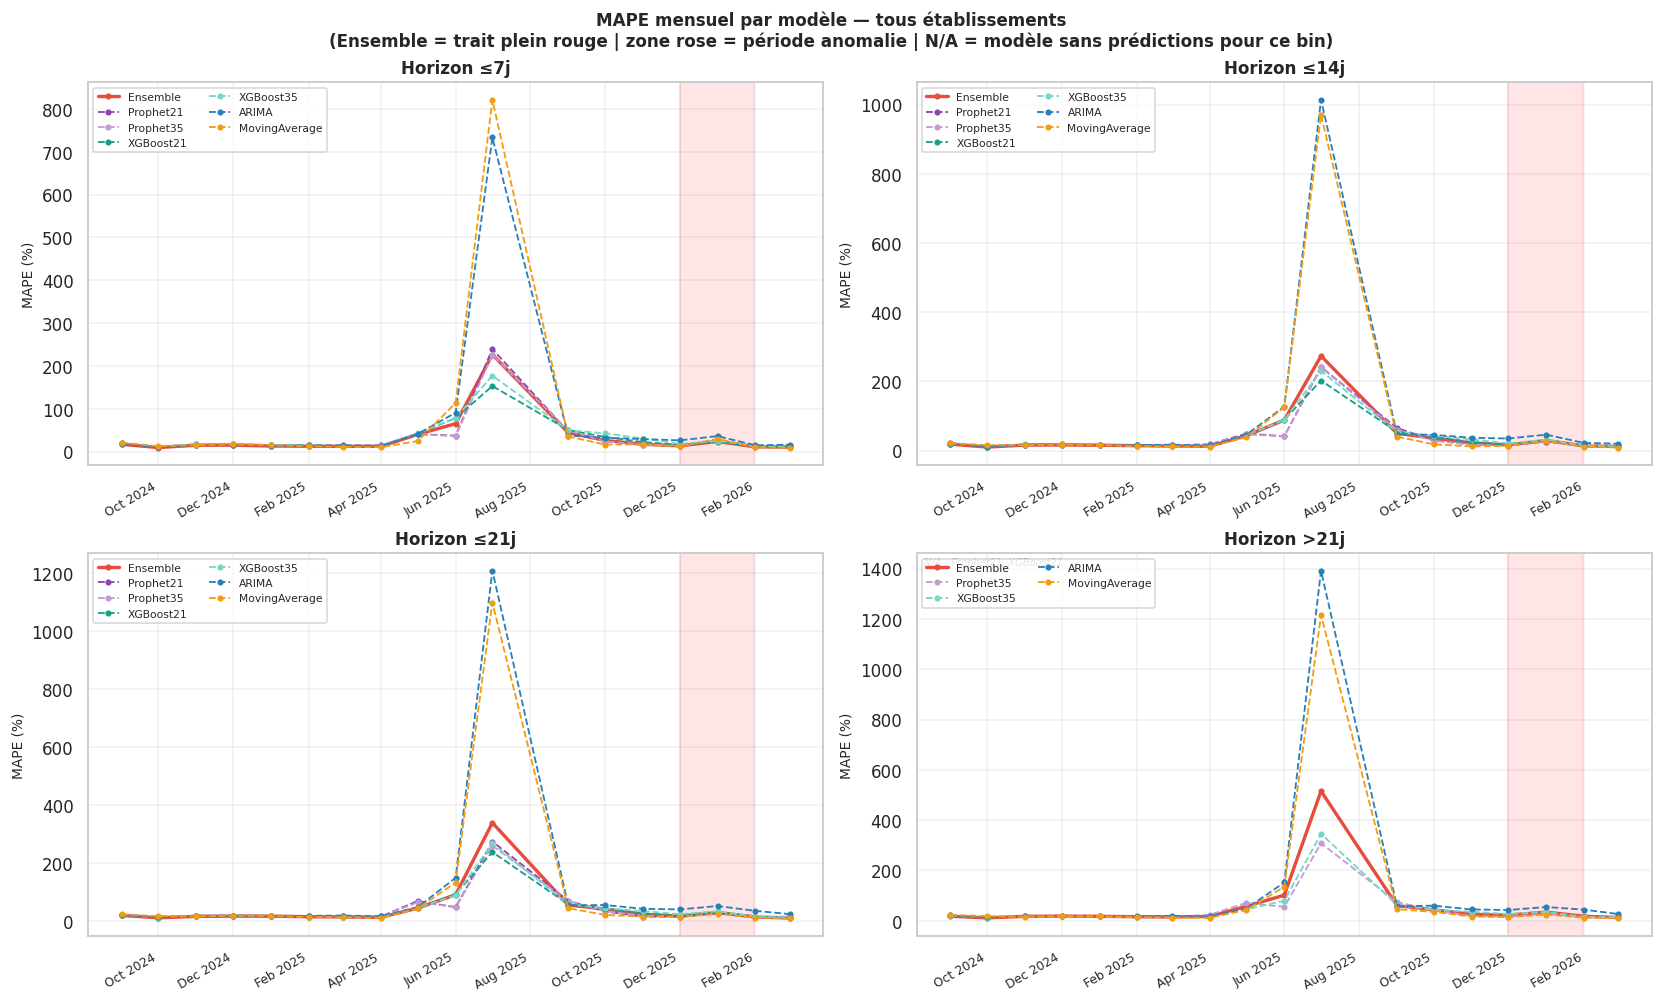

In [19]:
MODEL_COLORS = {
    'Ensemble':      '#E74C3C',
    'Prophet21':     '#8E44AD',
    'Prophet35':     '#C39BD3',
    'XGBoost21':     '#16A085',
    'XGBoost35':     '#76D7C4',
    'ARIMA':         '#2980B9',
    'MovingAverage': '#F39C12',
}
# Ordre d'affichage : Ensemble en premier pour qu'il soit au-dessus
models_present = [m for m in MODEL_COLORS if m in monthly_mape['model'].unique()]

fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)
axes_flat = axes.flatten()

for ax, b in zip(axes_flat, BIN_ORDER):
    sub_b = monthly_mape[monthly_mape['horizon_bin'] == b]
    has_data = sub_b['model'].unique()

    for model in models_present:
        sub_m = sub_b[sub_b['model'] == model].sort_values('month_dt')
        if sub_m.empty:
            # Annoter que ce modèle n'a pas de données pour ce bin
            continue
        lw = 2.2 if model == 'Ensemble' else 1.2
        ls = '-'  if model == 'Ensemble' else '--'
        ax.plot(
            sub_m['month_dt'], sub_m['mape'],
            color=MODEL_COLORS[model], lw=lw, linestyle=ls,
            marker='o', markersize=3, label=model,
        )

    # Modèles absents pour ce bin : mentionnés dans la légende avec marqueur vide
    absent = [m for m in models_present if m not in has_data]
    if absent:
        ax.text(
            0.01, 0.99, 'N/A : ' + ', '.join(absent),
            transform=ax.transAxes, fontsize=6.5, va='top',
            color='grey', style='italic',
        )

    ax.axvspan(ANOMALY_START, ANOMALY_END, alpha=0.10, color='red')
    ax.set_title(f'Horizon {b}', fontweight='bold', fontsize=11)
    ax.set_ylabel('MAPE (%)', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
    ax.legend(fontsize=7, ncol=2, loc='upper left')
    ax.grid(alpha=0.3)

fig.suptitle(
    'MAPE mensuel par modèle — tous établissements\n'
    '(Ensemble = trait plein rouge | zone rose = période anomalie | N/A = modèle sans prédictions pour ce bin)',
    fontsize=11, fontweight='bold'
)
plt.show()


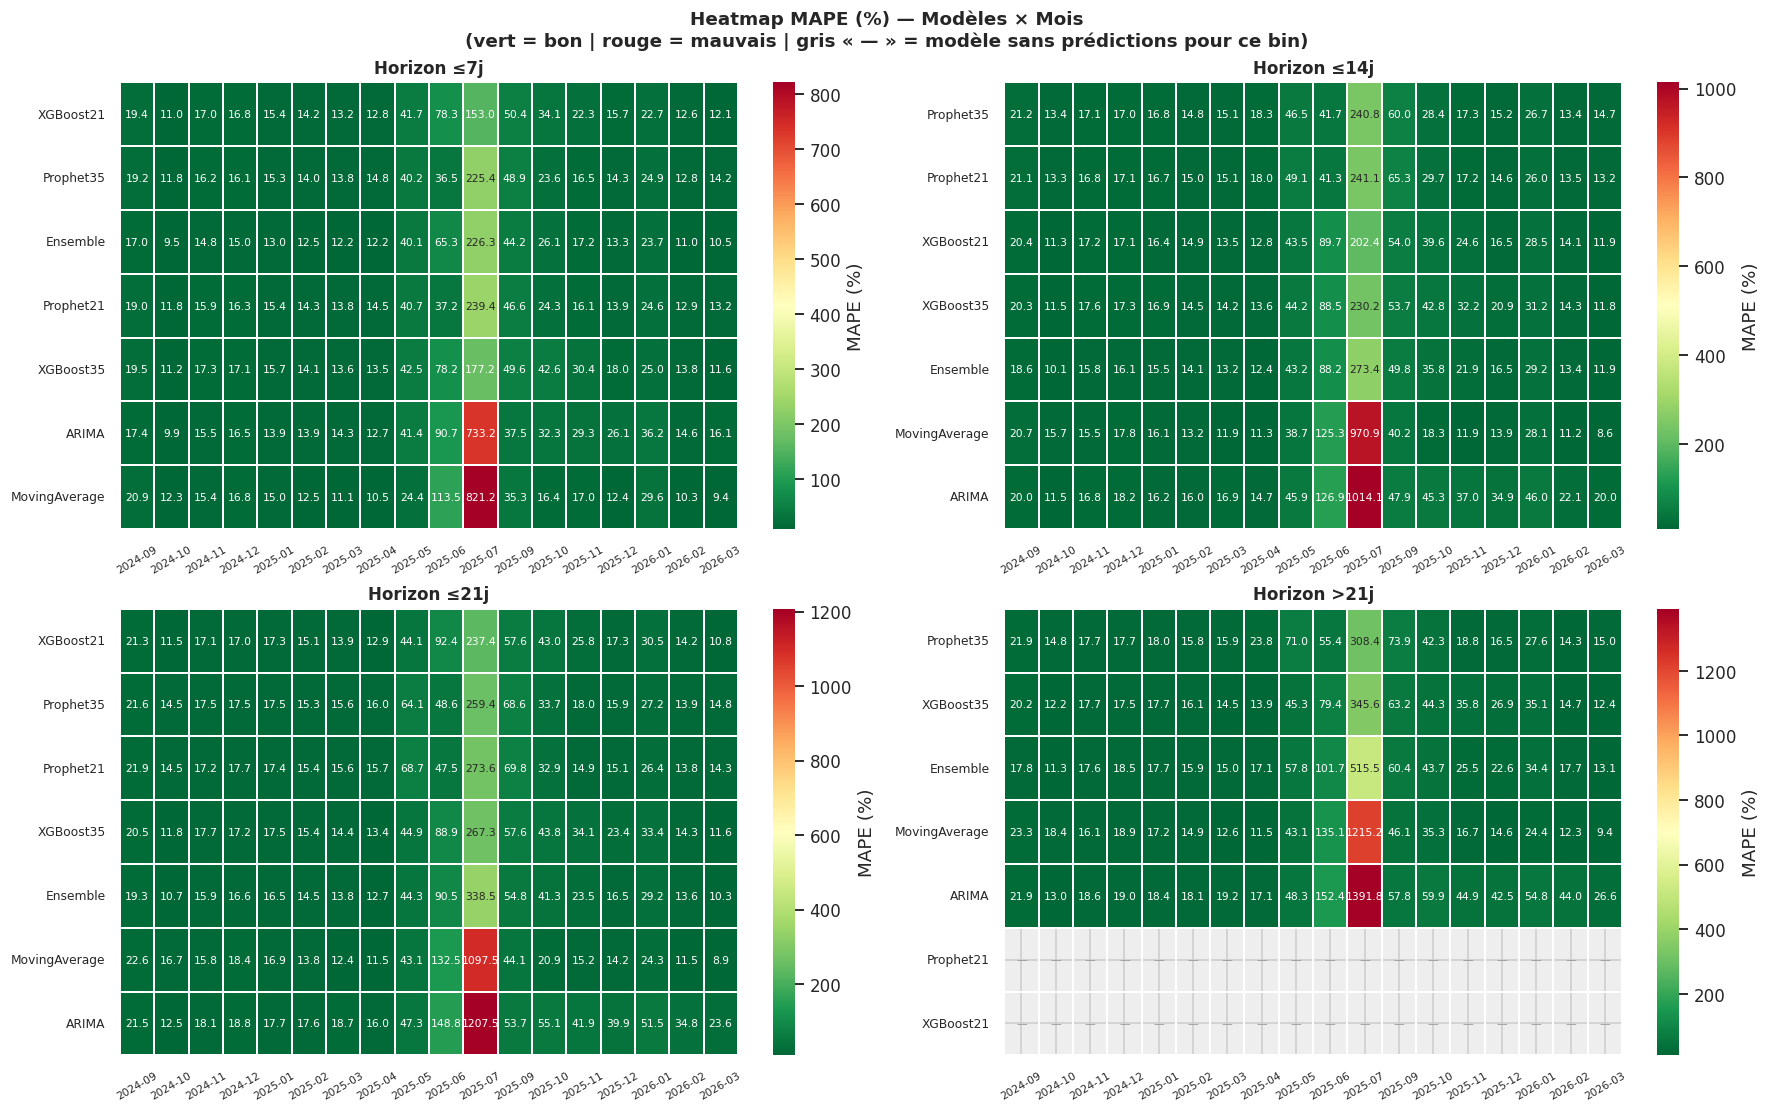

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
axes_flat = axes.flatten()

for ax, b in zip(axes_flat, BIN_ORDER):
    sub_b = monthly_mape[monthly_mape['horizon_bin'] == b]
    pivot = sub_b.pivot(index='model', columns='month', values='mape')
    pivot.columns = [str(m) for m in pivot.columns]

    # Ajouter les modèles absents comme lignes NaN pour les montrer explicitement
    for m in models_present:
        if m not in pivot.index:
            pivot.loc[m] = np.nan

    # Trier : modèles avec données d'abord (par MAPE moyen), puis absents
    has_data_models = pivot.dropna(how='all').index
    no_data_models  = pivot[pivot.isna().all(axis=1)].index
    order = list(pivot.loc[has_data_models].mean(axis=1).sort_values().index) + list(no_data_models)
    pivot = pivot.loc[order]

    mask = pivot.isna()
    sns.heatmap(
        pivot,
        ax=ax,
        cmap='RdYlGn_r',
        annot=True,
        fmt='.1f',
        linewidths=0.3,
        linecolor='white',
        mask=mask,
        cbar_kws={'label': 'MAPE (%)'},
        annot_kws={'size': 7},
    )
    # Colorier les cellules NaN en gris clair
    ax.patch.set_facecolor('#EEEEEE')
    # Annoter les cellules NaN avec « — »
    for row_i, row_name in enumerate(pivot.index):
        for col_i, col_name in enumerate(pivot.columns):
            if pd.isna(pivot.loc[row_name, col_name]):
                ax.text(
                    col_i + 0.5, row_i + 0.5, '—',
                    ha='center', va='center', fontsize=7, color='#999999'
                )
    ax.set_title(f'Horizon {b}', fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.tick_params(axis='y', labelsize=8)

fig.suptitle(
    'Heatmap MAPE (%) — Modèles × Mois\n'
    '(vert = bon | rouge = mauvais | gris « — » = modèle sans prédictions pour ce bin)',
    fontsize=12, fontweight='bold'
)
plt.show()


## 13. Synthèse

Remplir après examen des graphiques.

In [21]:
print("=== Résumé statistique ===")
print(f"\nMAPE global Ensemble ≤7j :")
for label, t0, t1 in [
    ('Sept–Nov 2025',       pd.Timestamp('2025-09-01'), pd.Timestamp('2025-11-30')),
    ('Déc 2025 – Jan 2026', ANOMALY_START,              ANOMALY_END),
    ('Fév–Mar 2026',        pd.Timestamp('2026-02-01'), pd.Timestamp('2026-03-31')),
]:
    s = ens7[(ens7['target_date'] >= t0) & (ens7['target_date'] <= t1)]
    print(f"  {label:30s}: MAPE = {mape(s['effectif_reel'], s['prediction']):.1f}%  "
          f"| Biais moyen = {(s['prediction'] - s['effectif_reel']).mean():.1f}  "
          f"| N = {len(s):,}")

print("\n=== MAPE Anomalie par type de jour ===")
for dtype in type_order:
    s = df_anom[df_anom['day_type'] == dtype]
    if len(s) > 0:
        print(f"  {dtype:25s}: MAPE = {mape(s['effectif_reel'], s['prediction']):.1f}%  N = {len(s)}")

=== Résumé statistique ===

MAPE global Ensemble ≤7j :
  Sept–Nov 2025                 : MAPE = 30.2%  | Biais moyen = -5.9  | N = 8,920
  Déc 2025 – Jan 2026           : MAPE = 19.3%  | Biais moyen = -1.9  | N = 5,796
  Fév–Mar 2026                  : MAPE = 10.9%  | Biais moyen = 3.4  | N = 2,158

=== MAPE Anomalie par type de jour ===
  Normal                   : MAPE = 19.3%  N = 5796


---
### Pistes d'investigation

- [ ] **Vacances de Noël non capturées** : si `is_holyday = 0` sur des jours réellement fermés → les features (moyennes mobiles) surestiment l'activité attendue
- [ ] **Les autres modèles sont-ils aussi élevés ?** (section 5) → si oui, le problème est dans les features partagées (moyennes mobiles calculées sur une période haute) ; si Ensemble seul → problème de pondération / empilement
- [ ] **Décalage temporel des moyennes mobiles** : `mobile_mean_42_shifted_21` est calculée 21 jours avant → en décembre, elle reflète novembre (période haute), pas les vacances
- [ ] **Établissements non-ouverts** sur la période sans flag adéquat (section 9 → croiser avec les établissements les plus touchés)
- [ ] **Correction possible** : ajouter un masque de fermeture explicite ou re-entraîner avec les vrais jours de fermeture de déc 2024 comme référence